# Automated Essay Scoring for TEF Writing Tasks

This project explores the use of Natural Language Processing and Transformer-based models to automatically predict the writing score of candidates taking the Test d’Évaluation de Français (TEF).

The objective is to build a machine learning pipeline capable of estimating the overall writing score based on the candidate's written response and contextual information provided in the prompt.

The project includes:

- Data cleaning and preparation
- Exploratory data analysis
- Baseline modeling
- Fine-tuning of a CamemBERT model for score prediction
- Subscore prediction using a dedicated neural architecture

This work aims to demonstrate how modern NLP models can assist in automated assessment while maintaining interpretability and robustness.

## 1. Data Loading and Preparation

In this section, we load the dataset containing the written responses and the corresponding evaluation scores.

The initial steps include:

- Importing the dataset
- Inspecting the structure of the data
- Cleaning missing or inconsistent values
- Preparing the textual inputs used for model training

### a) Import du fichier excel contenant les notes des candidats

In [1]:
import os
os.environ["USE_TF"] = "0"
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("📡 Device utilisé :", device)


📡 Device utilisé : mps


In [3]:
import pandas as pd

# Spécifiez le chemin du fichier Excel
excel_file_path = '/Users/raymondmauricefaye/Desktop/PIVS/DATA/Données_initiales/Evaluations EE TEF 1er semestre 202422418 candidats feuille notes anonymisés v2.xlsx'

# Charger le fichier Excel dans un DataFrame
df_excel = pd.read_excel(excel_file_path)

# Afficher les premières lignes du DataFrame
df_excel.head()



,numero_cand.fictif,session_id,code_produit,section,fda_evaluator_id,note_cap,note_syn,note_lex,note_coh,score_brut,score_section_eval,score_evaluateur,score_epreuve,Unnamed: 13,Unnamed: 14,Unnamed: 15,Seuils,brut,TEF
0,1,7000007,TEFCAN,EE1,177,11,11,11,11,137.5,349,645.0,660.0,NaN,NaN,NaN,Min,0,0
1,1,7000007,TEFCAN,EE1,178,11,11,11,10,135.5,341,674.0,660.0,NaN,NaN,NaN,A1,12.5,50
2,1,7000007,TEFCAN,EE2,177,10,9,10,10,123.0,296,645.0,660.0,NaN,NaN,NaN,A2,25,100
3,1,7000007,TEFCAN,EE2,178,11,10,11,10,133.5,333,674.0,660.0,NaN,NaN,NaN,B1,50,150
4,2,7000007,TEFCAN,EE1,177,10,10,10,10,125.0,300,588.0,627.0,NaN,NaN,NaN,B2,75,200


In [5]:
df_excel.shape

(85725, 19)

In [7]:
df_excel.isnull().sum()

numero_cand.fictif        0
session_id                0
code_produit              0
section                   0
fda_evaluator_id          0
note_cap                  0
note_syn                  0
note_lex                  0
note_coh                  0
score_brut                0
score_section_eval        0
score_evaluateur        193
score_epreuve            42
Unnamed: 13           85725
Unnamed: 14           85725
Unnamed: 15           85725
Seuils                85710
brut                  85709
TEF                   85716
dtype: int64

In [9]:
# Supprimer les colonnes inutiles qui sont entièrement vides ou inutiles pour l'entraînement de notre modèle
df_excel_cleaned = df_excel.drop(columns=['Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Seuils', 'brut', 'TEF', 'code_produit'], errors='ignore')

# Vérifier les colonnes restantes
df_excel_cleaned.head()


,numero_cand.fictif,session_id,section,fda_evaluator_id,note_cap,note_syn,note_lex,note_coh,score_brut,score_section_eval,score_evaluateur,score_epreuve
0,1,7000007,EE1,177,11,11,11,11,137.5,349,645.0,660.0
1,1,7000007,EE1,178,11,11,11,10,135.5,341,674.0,660.0
2,1,7000007,EE2,177,10,9,10,10,123.0,296,645.0,660.0
3,1,7000007,EE2,178,11,10,11,10,133.5,333,674.0,660.0
4,2,7000007,EE1,177,10,10,10,10,125.0,300,588.0,627.0


In [11]:
df_excel_cleaned = df_excel_cleaned.dropna(subset=['score_evaluateur', 'score_epreuve'])


In [13]:
df_excel_cleaned.isnull().sum()

numero_cand.fictif    0
session_id            0
section               0
fda_evaluator_id      0
note_cap              0
note_syn              0
note_lex              0
note_coh              0
score_brut            0
score_section_eval    0
score_evaluateur      0
score_epreuve         0
dtype: int64

In [15]:
df_excel_cleaned.shape

(85532, 12)

### b) Vérifier le nombre de notes par candidat

In [18]:
# Compter le nombre de notes par candidat
notes_par_candidat = df_excel_cleaned['numero_cand.fictif'].value_counts()

# Afficher les candidats qui ont un nombre différent de 4
candidats_a_exclure = notes_par_candidat[notes_par_candidat != 4]
print(f"Nombre de candidats à exclure : {len(candidats_a_exclure)}")
print(candidats_a_exclure.head(10))  # Vérifier un échantillon


Nombre de candidats à exclure : 20
numero_cand.fictif
9020     8
8316     8
17769    8
14132    8
15018    8
17176    8
5564     8
17875    8
12194    8
10577    8
Name: count, dtype: int64


Il y a 20 candidats qui n'ont pas 4 notes (ils en ont 8, ce qui indique qu'ils ont probablement été évalués deux fois plus que prévu). Nous allons maintenant les supprimer de notre fichier.

### c) Supprimer les candidats ayant ≠ 4 notes

In [22]:
# Créer une liste des candidats à exclure (ceux qui n'ont pas 4 notes)
candidats_a_exclure = notes_par_candidat[notes_par_candidat != 4].index

# Filtrer le DataFrame pour ne garder que les candidats ayant exactement 4 notes
df_excel_cleaned = df_excel_cleaned[~df_excel_cleaned['numero_cand.fictif'].isin(candidats_a_exclure)]

# Vérifier le nombre de lignes après suppression
print("Nouveau nombre de lignes après suppression :", df_excel_cleaned.shape[0])


Nouveau nombre de lignes après suppression : 85396


In [24]:
# Vérifier que tous les candidats restants ont exactement 4 notes
notes_par_candidat_apres = df_excel_cleaned['numero_cand.fictif'].value_counts()

if (notes_par_candidat_apres != 4).sum() == 0:
    print("✅ Tous les candidats restants ont exactement 4 notes.")
else:
    print("❌ Erreur : Il reste encore des candidats avec un nombre incorrect de notes.")


✅ Tous les candidats restants ont exactement 4 notes.


In [26]:
df_excel_cleaned.shape

(85396, 12)

### Import du fichier csv contenant les sujets

In [29]:
import pandas as pd

# Spécifiez le chemin du fichier CSV
csv_file_path = '/Users/raymondmauricefaye/Desktop/PIVS/DATA/Données_initiales/Sujets_EE_TEF.csv'

# Charger le fichier CSV dans un DataFrame
df_csv = pd.read_csv(csv_file_path, encoding='ISO-8859-1', sep=';')

# Afficher les premières lignes du DataFrame
df_csv.head()


#os.chdir('/Users/raymondmauricefaye/Desktop/PIVS/DATA/Données_initiales')
#csv_data = pd.read_csv("Sujets_EE_TEF.csv")

,Num_Sujet,Nom_Sujet,Introduction,Texte1,Texte2
0,EE20127A,Un trésor original,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un trésor original (La Havane, Cuba) Deux écol..."
1,EE20127B,Dans 20 ans,Vous avez lu dans un journal l'affirmation sui...,"« Dans 20 ans, il ny aura plus de livres »",Écrivez une lettre au journal pour dire ce que...
2,EE20128A,Une vieille connaissance,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Une vieille connaissance (Angers, France) Un p..."
3,EE20128B,Chaque citoyen,Vous avez lu dans un journal l'affirmation sui...,« Chaque citoyen devrait sengager dans une as...,Écrivez une lettre au journal pour dire ce que...
4,EE20129A,Un rendez-vous urgent,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar..."


In [31]:
df_csv.shape

(111, 5)

In [33]:
df_csv.isnull().sum()

Num_Sujet       0
Nom_Sujet       0
Introduction    0
Texte1          0
Texte2          0
dtype: int64

### Import du fichier JSON contenant les productions écrites

In [37]:
import os
import pandas as pd
import json
from glob import glob

# Chemin d'accès vers mon répertoire 
os.chdir('/Users/raymondmauricefaye/Desktop/PIVS/DATA/Données_initiales/JSON_anonymis')

# Chargement de tous les fichiers JSON
json_files = glob('*.txt')

# Création d'une liste pour stocker les données
all_data = []

# Lecture de chaque fichier JSON et chargement dans un DataFrame
for file in json_files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_data.append(pd.json_normalize(data))

# Concaténation de toutes les données dans un seul DataFrame
final_data = pd.concat(all_data, ignore_index=True)

# Affichage du DataFrame résultant
final_data.head()


,candidate,center,content,date,epreuve,session
0,[11303],"[IFT - Quartier administratif, Avenue de Gaull...","[{'subject': 'EE20153B', 'title': 'TEF Canada ...",[2024-03-21],[TEF Canada],[7004962]
1,[3644],[Alger Val d'Hydra - EDUCALGPRO - 16016 ALGER ...,"[{'subject': 'EE20129A', 'title': 'TEF Canada ...",[2024-01-22],[TEF Canada],[7001192]
2,[19987],[4e étage immeuble CBC près de landmark - 140 ...,"[{'subject': 'EE20143A', 'title': 'TEF Canada ...",[2024-06-13],[TEF Canada],[7008714]
3,[18441],[Lab 503 / 5ième étage - 443 University Avenue...,"[{'subject': 'EE20170A', 'title': 'TEF Canada ...",[2024-06-11],[TEF Canada],[7007506]
4,[5235],[80 boulevard de l'Yser - 76000 rouen - FRA],"[{'subject': 'EE20131A', 'title': 'TEF Canada ...",[2024-02-20],[TEF Canada],[7000435]


In [39]:
# Supprimer les colonnes 'date', 'epreuve' et 'session'
final_data = final_data.drop(columns=['date', 'epreuve', 'session', 'center'], errors='ignore')

# Vérifier le résultat
final_data.head()


,candidate,content
0,[11303],"[{'subject': 'EE20153B', 'title': 'TEF Canada ..."
1,[3644],"[{'subject': 'EE20129A', 'title': 'TEF Canada ..."
2,[19987],"[{'subject': 'EE20143A', 'title': 'TEF Canada ..."
3,[18441],"[{'subject': 'EE20170A', 'title': 'TEF Canada ..."
4,[5235],"[{'subject': 'EE20131A', 'title': 'TEF Canada ..."


In [41]:
final_data.shape

(21411, 2)

In [43]:
final_data.isnull().sum()

candidate    0
content      0
dtype: int64

In [45]:
# Extraire l'identifiant unique du candidat
final_data['candidate'] = final_data['candidate'].apply(lambda x: x[0] if isinstance(x, list) else x)

# Vérifier le résultat
print(final_data[['candidate']].head())


   candidate
0      11303
1       3644
2      19987
3      18441
4       5235


In [47]:
final_data.head()

,candidate,content
0,11303,"[{'subject': 'EE20153B', 'title': 'TEF Canada ..."
1,3644,"[{'subject': 'EE20129A', 'title': 'TEF Canada ..."
2,19987,"[{'subject': 'EE20143A', 'title': 'TEF Canada ..."
3,18441,"[{'subject': 'EE20170A', 'title': 'TEF Canada ..."
4,5235,"[{'subject': 'EE20131A', 'title': 'TEF Canada ..."


###  Étape 1 : Vérifier les différences entre final_data et df_excel_cleaned
Nous allons comparer les candidats présents dans les deux fichiers.

In [51]:
# Convertir les identifiants candidats en string pour éviter les erreurs de comparaison
final_data['candidate'] = final_data['candidate'].astype(str)
df_excel_cleaned['numero_cand.fictif'] = df_excel_cleaned['numero_cand.fictif'].astype(str)

# Extraire les listes d'identifiants
candidats_json = set(final_data['candidate'].unique())
candidats_excel = set(df_excel_cleaned['numero_cand.fictif'].unique())

# Identifier les candidats présents dans JSON mais absents dans Excel
candidats_en_trop = candidats_json - candidats_excel
print(f"Nombre de candidats en trop dans JSON : {len(candidats_en_trop)}")
print(f"Candidats en trop (JSON mais pas dans Excel) : {list(candidats_en_trop)[:10]}")  # Afficher un échantillon

# Identifier les candidats présents dans Excel mais absents dans JSON
candidats_manquants = candidats_excel - candidats_json
print(f"Nombre de candidats manquants dans JSON : {len(candidats_manquants)}")
print(f"Candidats manquants (Excel mais pas dans JSON) : {list(candidats_manquants)[:10]}")  # Afficher un échantillon


Nombre de candidats en trop dans JSON : 62
Candidats en trop (JSON mais pas dans Excel) : ['4490', '9911', '8316', '18108', '1946', '1202', '4854', '21417', '11076', '335']
Nombre de candidats manquants dans JSON : 0
Candidats manquants (Excel mais pas dans JSON) : []


Parfait, l’analyse montre que :

✅ Aucun candidat n’est manquant dans final_data → Tous les candidats du fichier Excel ont bien une production écrite.
❌ 62 candidats sont en trop dans final_data → Ces candidats n’ont pas de notes dans le fichier Excel.

Nous allons maintenant supprimer ces 62 candidats en trop pour assurer une correspondance parfaite entre les fichiers.

In [54]:
# Supprimer les candidats qui ne sont pas présents dans df_excel_cleaned
final_data = final_data[final_data['candidate'].isin(df_excel_cleaned['numero_cand.fictif'])]

# Vérifier après suppression
print("Nombre de candidats après nettoyage :", final_data['candidate'].nunique())


Nombre de candidats après nettoyage : 21349


In [56]:
final_data.shape

(21349, 2)

## Étape 2 : Vérification finale
Après suppression, nous faisons une dernière vérification pour s’assurer que tous les candidats sont bien alignés.

In [59]:
# Vérifier à nouveau si des candidats restent en trop
candidats_json_final = set(final_data['candidate'].unique())
candidats_excel_final = set(df_excel_cleaned['numero_cand.fictif'].unique())

assert candidats_json_final == candidats_excel_final, "❌ Il reste encore des différences entre les fichiers !"

print("✅ Tous les candidats de JSON et Excel correspondent parfaitement !")


✅ Tous les candidats de JSON et Excel correspondent parfaitement !


## Séparer les productions écrites en 2 lignes distinctes

In [63]:
# Vérifier que content est bien une liste
final_data['content'] = final_data['content'].apply(lambda x: x if isinstance(x, list) else [])

# Décomposer les productions écrites en plusieurs lignes
df_exploded = final_data.explode('content')

# Extraire les champs subject, title et response
df_exploded['subject'] = df_exploded['content'].apply(lambda x: x.get('subject') if isinstance(x, dict) else None)
df_exploded['title'] = df_exploded['content'].apply(lambda x: x.get('title') if isinstance(x, dict) else None)
df_exploded['response'] = df_exploded['content'].apply(lambda x: x.get('response') if isinstance(x, dict) else None)

# Supprimer l'ancienne colonne 'content'
df_exploded = df_exploded.drop(columns=['content'])

# Vérifier le résultat
df_exploded.head()


,candidate,subject,title,response
0,11303,EE20153B,TEF Canada - TEF_EE2,"A l'attention de la rédaction, je v..."
0,11303,EE20160A,TEF Canada - TEF_EE1,En effet étant en route pour leur domicile ...
1,3644,EE20129A,TEF Canada - TEF_EE1,"une arme. \nEn effet, le jeune homme dépassant..."
1,3644,EE20128B,TEF Canada - TEF_EE2,"Depuis un certains moments, je remarque que le..."
2,19987,EE20143A,TEF Canada - TEF_EE1,Patrick est un petit garcon de 8 ans qui faisa...


In [65]:
# Supprimer la colonne 'center'
#df_exploded = df_exploded.drop(columns=['title'], errors='ignore')

# Vérifier le résultat
#df_exploded.head()


In [67]:
df_exploded.shape

(42698, 4)

In [69]:
df_exploded.isna().sum()

candidate      0
subject      239
title          0
response       0
dtype: int64

In [71]:
# Trouver les candidats avec une production sans sujet
candidats_incomplets = df_exploded[df_exploded['subject'].isna()]['candidate'].unique()

# Supprimer toutes les lignes de ces candidats dans df_exploded
df_exploded = df_exploded[~df_exploded['candidate'].isin(candidats_incomplets)]


## 2) Jointure entre mes différents DataFrame

### Jointure entre les productions écrites (JSON) et les sujets (CSV)

In [75]:
# Vérifier les types de données
print(df_exploded['subject'].dtype)
print(df_csv['Num_Sujet'].dtype)

# Vérifier quelques valeurs des deux colonnes
print(df_exploded['subject'].unique()[:10])
print(df_csv['Num_Sujet'].unique()[:10])


object
object
['EE20153B' 'EE20160A' 'EE20129A' 'EE20128B' 'EE20143A' 'EE20160B'
 'EE20170A' 'EE20182B' 'EE20131A' 'EE20131B']
['EE20127A' 'EE20127B' 'EE20128A' 'EE20128B' 'EE20129A' 'EE20129B'
 'EE20130A' 'EE20130B' 'EE20131A' 'EE20131B']


In [77]:
# Supprimer les espaces potentiels autour des valeurs
df_exploded['subject'] = df_exploded['subject'].str.strip()
df_csv['Num_Sujet'] = df_csv['Num_Sujet'].str.strip()

# Vérifier s'il y a des valeurs uniques dans l'une qui ne sont pas dans l'autre
subjects_final = set(df_exploded['subject'].unique())
subjects_csv = set(df_csv['Num_Sujet'].unique())

# Vérifier les sujets présents dans df_final mais absents de df_csv
missing_in_csv = subjects_final - subjects_csv
print(f"Sujets dans df_final mais absents de df_csv: {missing_in_csv}")

# Vérifier les sujets présents dans df_csv mais absents de df_final
missing_in_final = subjects_csv - subjects_final
print(f"Sujets dans df_csv mais absents de df_final: {missing_in_final}")


Sujets dans df_final mais absents de df_csv: set()
Sujets dans df_csv mais absents de df_final: {'EE20165B'}


In [79]:
# Supprimer les lignes avec le sujet 'EE20165B' dans df_csv
df_csv = df_csv[df_csv['Num_Sujet'] != 'EE20165B']

# Vérifier que le sujet a bien été supprimé
print("EE20165B" in df_csv['Num_Sujet'].values)  # Résultat attendu : False


False


In [81]:
df_merged1 = df_exploded.merge(df_csv, left_on='subject', right_on='Num_Sujet', how='left')

# Vérifier le résultat de la jointure
df_merged1.head()



,candidate,subject,title,response,Num_Sujet,Nom_Sujet,Introduction,Texte1,Texte2
0,11303,EE20153B,TEF Canada - TEF_EE2,"A l'attention de la rédaction, je v...",EE20153B,Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...
1,11303,EE20160A,TEF Canada - TEF_EE1,En effet étant en route pour leur domicile ...,EE20160A,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ..."
2,3644,EE20129A,TEF Canada - TEF_EE1,"une arme. \nEn effet, le jeune homme dépassant...",EE20129A,Un rendez-vous urgent,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar..."
3,3644,EE20128B,TEF Canada - TEF_EE2,"Depuis un certains moments, je remarque que le...",EE20128B,Chaque citoyen,Vous avez lu dans un journal l'affirmation sui...,« Chaque citoyen devrait sengager dans une as...,Écrivez une lettre au journal pour dire ce que...
4,19987,EE20143A,TEF Canada - TEF_EE1,Patrick est un petit garcon de 8 ans qui faisa...,EE20143A,Joyeux anniversaire Grand-maman !,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Joyeux anniversaire Grand-maman ! Les agents d...


In [83]:
print(df_merged1['Num_Sujet'].isna().sum(), "lignes n'ont pas trouvé de correspondance.")


0 lignes n'ont pas trouvé de correspondance.


In [85]:
df_merged1 = df_merged1.drop(columns=['Num_Sujet'])


In [87]:
df_merged1.shape

(42220, 8)

In [89]:
df_merged1.head()


,candidate,subject,title,response,Nom_Sujet,Introduction,Texte1,Texte2
0,11303,EE20153B,TEF Canada - TEF_EE2,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...
1,11303,EE20160A,TEF Canada - TEF_EE1,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ..."
2,3644,EE20129A,TEF Canada - TEF_EE1,"une arme. \nEn effet, le jeune homme dépassant...",Un rendez-vous urgent,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar..."
3,3644,EE20128B,TEF Canada - TEF_EE2,"Depuis un certains moments, je remarque que le...",Chaque citoyen,Vous avez lu dans un journal l'affirmation sui...,« Chaque citoyen devrait sengager dans une as...,Écrivez une lettre au journal pour dire ce que...
4,19987,EE20143A,TEF Canada - TEF_EE1,Patrick est un petit garcon de 8 ans qui faisa...,Joyeux anniversaire Grand-maman !,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Joyeux anniversaire Grand-maman ! Les agents d...


In [91]:
df_merged1.isnull().sum()

candidate       0
subject         0
title           0
response        0
Nom_Sujet       0
Introduction    0
Texte1          0
Texte2          0
dtype: int64

### Jointure entre df_merged1 (productions) et df_excel_cleaned (notes).

In [94]:
df_excel_cleaned.head()

,numero_cand.fictif,session_id,section,fda_evaluator_id,note_cap,note_syn,note_lex,note_coh,score_brut,score_section_eval,score_evaluateur,score_epreuve
0,1,7000007,EE1,177,11,11,11,11,137.5,349,645.0,660.0
1,1,7000007,EE1,178,11,11,11,10,135.5,341,674.0,660.0
2,1,7000007,EE2,177,10,9,10,10,123.0,296,645.0,660.0
3,1,7000007,EE2,178,11,10,11,10,133.5,333,674.0,660.0
4,2,7000007,EE1,177,10,10,10,10,125.0,300,588.0,627.0


Dans df_merged1, la colonne title contient : "TEF Canada - TEF_EE1" ou "TEF Canada - TEF_EE2"

Il faut donc extraire "EE1" ou "EE2" à la fin de title pour obtenir la section

Cette section servira à faire la jointure avec df_excel_cleaned, avec la colonne section

In [97]:
df_merged1['section'] = df_merged1['title'].str.extract(r'(EE[12])')

Renommer df_excel_cleaned pour la jointure

In [100]:
# Harmoniser les noms des colonnes
df_excel_cleaned = df_excel_cleaned.rename(columns={
    'numero_cand.fictif': 'candidate'
})


In [102]:
df_merged1['candidate'] = df_merged1['candidate'].astype(int)
df_excel_cleaned['candidate'] = df_excel_cleaned['candidate'].astype(int)


In [365]:
# Jointure sur candidate + section
df_final_notes = df_merged1.merge(df_excel_cleaned, on=['candidate', 'section'], how='left')

# Vérifier le résultat
print(df_final_notes.shape)
df_final_notes.head()


(84440, 19)


,candidate,subject,title,response,Nom_Sujet,Introduction,Texte1,Texte2,section,session_id,fda_evaluator_id,note_cap,note_syn,note_lex,note_coh,score_brut,score_section_eval,score_evaluateur,score_epreuve
0,11303,EE20153B,TEF Canada - TEF_EE2,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,EE2,7004962,7083,9,8,9,9,110.5,271,521.0,542.0
1,11303,EE20153B,TEF Canada - TEF_EE2,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,EE2,7004962,7101,9,9,9,9,112.5,275,563.0,542.0
2,11303,EE20160A,TEF Canada - TEF_EE1,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",EE1,7004962,7083,8,8,8,8,100.0,250,521.0,542.0
3,11303,EE20160A,TEF Canada - TEF_EE1,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",EE1,7004962,7101,10,9,9,9,119.0,288,563.0,542.0
4,3644,EE20129A,TEF Canada - TEF_EE1,"une arme. \nEn effet, le jeune homme dépassant...",Un rendez-vous urgent,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar...",EE1,7001192,7085,11,9,11,11,133.5,333,667.0,592.0


In [367]:
print("Lignes sans correspondance après merge :", df_final_notes.isnull().sum())


Lignes sans correspondance après merge : candidate             0
subject               0
title                 0
response              0
Nom_Sujet             0
Introduction          0
Texte1                0
Texte2                0
section               0
session_id            0
fda_evaluator_id      0
note_cap              0
note_syn              0
note_lex              0
note_coh              0
score_brut            0
score_section_eval    0
score_evaluateur      0
score_epreuve         0
dtype: int64


#### Supprimer les colonnes inutiles

In [369]:
cols_to_drop = [
    'subject', 'title', 'section', 'session_id', 'fda_evaluator_id',
    'score_section_eval', 'score_evaluateur', 'score_epreuve'
]

df_model = df_final_notes.drop(columns=cols_to_drop)


In [371]:
df_model

,candidate,response,Nom_Sujet,Introduction,Texte1,Texte2,note_cap,note_syn,note_lex,note_coh,score_brut
0,11303,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,9,8,9,9,110.5
1,11303,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,9,9,9,9,112.5
2,11303,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",8,8,8,8,100.0
3,11303,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",10,9,9,9,119.0
4,3644,"une arme. \nEn effet, le jeune homme dépassant...",Un rendez-vous urgent,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar...",11,9,11,11,133.5
...,...,...,...,...,...,...,...,...,...,...,...
84435,19746,06/08/2024\n \nSujet: Addict...,Addiction aux réseaux,Vous avez lu dans un journal l'affirmation sui...,« Addiction aux réseaux sociaux : les adultes ...,Écrivez une lettre au journal pour dire ce que...,6,6,6,6,75.0
84436,16475,Le canapé acheté à un prix très abordable pa...,Une très bonne affaire,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Une très bonne affaire Un retraité de Vesoul (...,8,8,7,8,98.0
84437,16475,Le canapé acheté à un prix très abordable pa...,Une très bonne affaire,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Une très bonne affaire Un retraité de Vesoul (...,8,7,8,8,98.0
84438,16475,"Bonjour Monsieur, j ai lu dans dans un journal...",Dans cette société des écrans,Vous avez lu dans un journal l'affirmation sui...,"« Dans cette société des écrans et de limage,...",Écrivez une lettre au journal pour dire ce que...,7,7,7,7,87.5


In [375]:
# Compter le nombre d'occurrences par candidat
counts = df_model['candidate'].value_counts()

# Vérifier si tous ont exactement 4 lignes
if (counts == 4).all():
    print("✅ Tous les candidats apparaissent exactement 4 fois.")
else:
    print("❌ Certains candidats n'ont pas exactement 4 lignes.")
    # Afficher ceux qui n'ont pas 4 lignes
    print(counts[counts != 4])

✅ Tous les candidats apparaissent exactement 4 fois.


In [384]:
# Étape 1 : calculer la moyenne des notes par candidat et par sujet
df_notes_mean = (
    df_model.groupby(['candidate', 'Nom_Sujet'], as_index=False)
    [['note_cap', 'note_syn', 'note_lex', 'note_coh', 'score_brut']]
    .mean()
)

# Étape 2 : récupérer les colonnes descriptives (une seule ligne par candidat/sujet)
df_texts = (
    df_model.groupby(['candidate', 'Nom_Sujet'], as_index=False)
    .first()[['candidate', 'Nom_Sujet', 'response', 'Introduction', 'Texte1', 'Texte2']]
)

# Étape 3 : fusionner les deux dataframes
df_final = pd.merge(df_texts, df_notes_mean, on=['candidate', 'Nom_Sujet'], how='inner')

# Étape 4 : afficher le résultat
df_final


,candidate,Nom_Sujet,response,Introduction,Texte1,Texte2,note_cap,note_syn,note_lex,note_coh,score_brut
0,1,Le travail à distance,"A Paris, le 10 novembre 2023,\nA l'attention d...",Vous avez lu dans un journal l'affirmation sui...,« Le travail à distance devrait être la règle ...,Écrivez une lettre au journal pour dire ce que...,10.5,9.5,10.5,10.0,128.25
1,1,Un rendez-vous urgent,"En effet, ce motard avait sur sa main gauche u...",Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar...",11.0,11.0,11.0,10.5,136.50
2,2,Pour prévenir les crimes,"C'est un fait, les crimes sont de plus en plus...",Vous avez lu dans un journal l'affirmation sui...,"« Pour prévenir les crimes, il faudrait généra...",Écrivez une lettre au journal pour dire ce que...,10.5,9.5,10.0,9.5,126.25
3,2,Un trésor original,Alors même que leurs recherches etaient vaines...,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un trésor original (La Havane, Cuba) Deux écol...",10.5,10.0,10.5,10.0,129.25
4,3,Chaque citoyen,"Monsieur le rédacteur en chef,\nJe vous écris ...",Vous avez lu dans un journal l'affirmation sui...,« Chaque citoyen devrait sengager dans une as...,Écrivez une lettre au journal pour dire ce que...,9.0,8.5,9.0,9.0,111.50
...,...,...,...,...,...,...,...,...,...,...,...
42215,21415,Mauvaises perdantes,"Samedi dernier,vers 10 heures du matin, dans u...",Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Mauvaises perdantes (Fort-de-France, Martiniqu...",8.0,7.5,7.5,8.0,98.00
42216,21416,L'apprentissage d'un instrument de musique,"Bonjour Monsieur le rédacteur en chef, \n\nJe ...",Vous avez lu dans un journal l'affirmation sui...,« L'apprentissage d'un instrument de musique d...,Écrivez une lettre au journal pour dire ce que...,6.5,6.0,6.5,6.5,80.25
42217,21416,Une très bonne affaire,"La semaine dernière, Alfred, un retraité a vou...",Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Une très bonne affaire Un retraité de Vesoul (...,6.0,5.0,6.0,5.5,72.00
42218,21418,Déjà prisonnier !,"Mardi dernier, dans un petite ville près de la...",Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Déjà prisonnier ! (Gouda, Pays-Bas) Les habita...",6.5,5.0,6.0,5.5,75.25


In [388]:
df_final.duplicated().sum()

0

# BASELINE POUR PREDIRE LE SCORE BRUT

## 1. Baseline Modeling

Before training a complex model, we establish a baseline to understand the predictive signal present in the dataset.

This step allows us to:

- Evaluate the difficulty of the task
- Compare the performance of advanced models against a simple reference
- Identify potential issues in the dataset

In [121]:
import pandas as pd

df_model = pd.read_csv("df_model_clean.csv")
df_model.head()

,candidate,response,Nom_Sujet,Introduction,Texte1,Texte2,score_brut
0,11303,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,110.5
1,11303,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,112.5
2,11303,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",100.0
3,11303,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",119.0
4,3644,"une arme. \nEn effet, le jeune homme dépassant...",Un rendez-vous urgent,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar...",133.5


## 2. Dataset Construction

After cleaning the data, we construct the final dataset used for modeling.

The textual input is built by combining different contextual elements of the exam:

- Subject name
- Introduction
- Supporting texts
- Candidate response

These elements are merged into a single field (`full_input`) that will be used as input for the Transformer model.

## Étape 2 : Construire la colonne full_text
Concaténer Nom_Sujet + Introduction + Texte1 + Texte2 + response pour créer une seule séquence textuelle plus riche.

In [124]:
def build_full_text(row):
    return (
        f"[CONSIGNE]\n"
        f"Nom du sujet : {row['Nom_Sujet']}\n"
        f"Introduction : {row['Introduction']}\n"
        f"Texte 1 : {row['Texte1']}\n"
        f"Texte 2 : {row['Texte2']}\n\n"
        f"[REPONSE CANDIDAT]\n"
        f"{row['response']}"
    )

df_model['full_text'] = df_model.apply(build_full_text, axis=1)


## Étape 3 : Garder uniquement ce qui nous est utile pour le modèle

In [127]:
df_model = df_model[['full_text', 'score_brut']]


In [129]:
df_model.head()

,full_text,score_brut
0,[CONSIGNE]\nNom du sujet : Avoir du talent\nIn...,110.5
1,[CONSIGNE]\nNom du sujet : Avoir du talent\nIn...,112.5
2,[CONSIGNE]\nNom du sujet : Passage secret\nInt...,100.0
3,[CONSIGNE]\nNom du sujet : Passage secret\nInt...,119.0
4,[CONSIGNE]\nNom du sujet : Un rendez-vous urge...,133.5


##  Étape 4 : Nettoyer légèrement les textes (retours à la ligne, espaces)

In [132]:
import re

def clean_text(text):
    text = re.sub(r'\n+', '\n', text)         # enlever les retours à la ligne multiples
    text = re.sub(r'\s+', ' ', text).strip()  # enlever les espaces multiples
    return text

df_model['full_text'] = df_model['full_text'].apply(clean_text)


#### Visualiser la distribution des scores

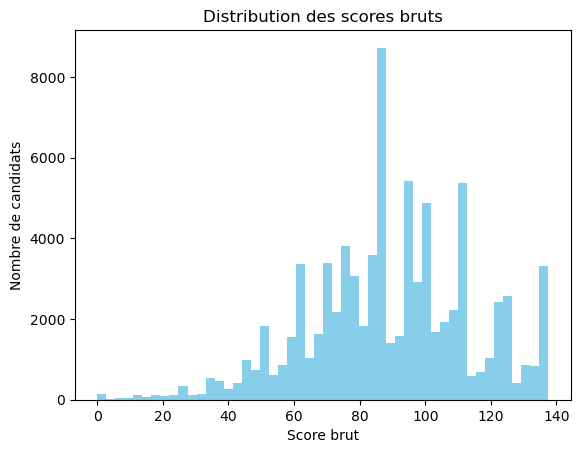

In [134]:
import matplotlib.pyplot as plt

plt.hist(df_model['score_brut'], bins=50, color='skyblue')
plt.title('Distribution des scores bruts')
plt.xlabel('Score brut')
plt.ylabel('Nombre de candidats')
plt.show()


Interprétation de la distribution des scores bruts
La distribution des scores bruts des candidats montre plusieurs caractéristiques intéressantes :

Distribution asymétrique :
On observe une asymétrie vers la droite (asymétrie positive), avec une majorité des candidats ayant des scores situés entre 60 et 110. Cela signifie que la plupart des productions écrites reçoivent une note dans la moyenne à supérieure.

Présence de pics récurrents :
On remarque des pics nets à certaines valeurs (autour de 85, 100, 120...). Cela peut refléter des effets de notation standardisée ou des seuils psychologiques dans l’évaluation, où les correcteurs attribuent fréquemment certaines notes « repères ».

Extrêmes peu fréquents :
Les scores très bas (< 30) et très hauts (> 130) sont très rares. Cela pourrait s’expliquer par le fait que très peu de productions sont complètement hors-sujet ou exceptionnellement brillantes selon les critères d’évaluation.

Pertinence pour le modèle :
Cette distribution montre que les données couvrent un éventail relativement large de scores, ce qui est une bonne chose pour entraîner un modèle de régression. Il est important que le modèle puisse apprendre à prédire des scores bas, moyens et élevés.

## ENTRAÎNEMENT DU MODÈLE

### Première étape exploratoire avec un modèle de base

#### 1. Découper les données

In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_model['full_text'],
    df_model['score_brut'],
    test_size=0.2,
    random_state=42
)


#### 2. Vectorisation des textes

In [144]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


#### 3. modèle de régression simple

In [146]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

model = Ridge()
model.fit(X_train_vec, y_train)

# Prédictions
y_pred = model.predict(X_test_vec)

# Évaluation
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


RMSE: 19.12
R²: 0.42


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


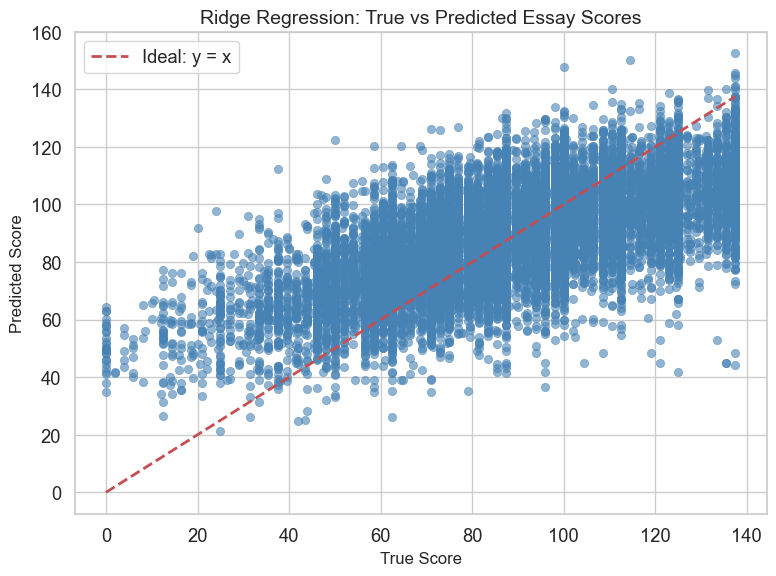

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set(style="whitegrid", font_scale=1.2)

# Créer une figure
plt.figure(figsize=(8, 6))

# Scatter plot des valeurs prédites vs vraies
sns.scatterplot(x=y_test, y=y_pred, color='steelblue', alpha=0.6, edgecolor=None)

# Ajouter la ligne y = x (parfaite prédiction)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal: y = x')

# Titres et légendes
plt.title('Ridge Regression: True vs Predicted Essay Scores', fontsize=14)
plt.xlabel('True Score', fontsize=12)
plt.ylabel('Predicted Score', fontsize=12)
plt.legend()
plt.tight_layout()

# Afficher
plt.show()


In [162]:
# Sauvegarde du graphique dans un dossier 'figures'
plt.savefig("/Users/raymondmauricefaye/Desktop/figures/ridge_true_vs_predicted.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

#### Analyse préliminaire avec modèle classique
Objectif
Avant d'entraîner un modèle basé sur CamemBERT, nous avons testé une approche classique de régression pour établir une première ligne de base (baseline). Cela permet de mieux évaluer la plus-value qu’un modèle pré-entraîné comme CamemBERT pourra apporter ensuite.

Modèle de régression de base

Séparation des données en ensemble d'entraînement (80%) et de test (20%).

Vectorisation des textes avec TfidfVectorizer (unigrammes et bigrammes, 5000 features max).

Entraînement d’un modèle de régression Ridge (régression linéaire avec régularisation L2).

Prédiction des scores sur les données de test.

Résultats obtenus
RMSE (Root Mean Squared Error) : 19.12
→ En moyenne, le modèle se trompe de ±19 points sur le score brut.

R² (Score de détermination) : 0.42
→ Le modèle explique environ 42% de la variance des scores bruts.

Interprétation
Ces résultats sont relativement faibles : un modèle linéaire sur du TF-IDF n’est pas capable de bien capturer les subtilités linguistiques qui influencent la notation d’une production écrite.

Cela justifie l’utilisation d’un modèle plus avancé, comme CamemBERT, qui comprend le contexte et la structure du langage.

In [451]:
# ------------------------------------------------------------
# Étape 2 : Vectorisation TF-IDF
# ------------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Dimensions TF-IDF : {X_train_vec.shape}")


Dimensions TF-IDF : (33776, 5000)


In [453]:
# ------------------------------------------------------------
# Étape 3 : Entraînement multi-sortie avec Ridge
# ------------------------------------------------------------
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Modèle multi-sortie
ridge_multi = MultiOutputRegressor(Ridge(alpha=1.0))
ridge_multi.fit(X_train_vec, y_train)

# Prédictions
y_pred = ridge_multi.predict(X_test_vec)

# Évaluation : RMSE, MAE, R2 pour chaque sous-note
import pandas as pd
results = []
for i, col in enumerate(y.columns):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    mae = np.mean(np.abs(y_test.iloc[:, i] - y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    results.append([col.upper(), rmse, mae, r2])

df_results = pd.DataFrame(results, columns=['Subscore', 'RMSE', 'MAE', 'R2'])
print(df_results)


   Subscore      RMSE       MAE        R2
0  NOTE_CAP  1.296192  1.015482  0.507113
1  NOTE_SYN  1.309950  1.040367  0.502085
2  NOTE_LEX  1.253965  0.991996  0.511738
3  NOTE_COH  1.302053  1.025556  0.505991


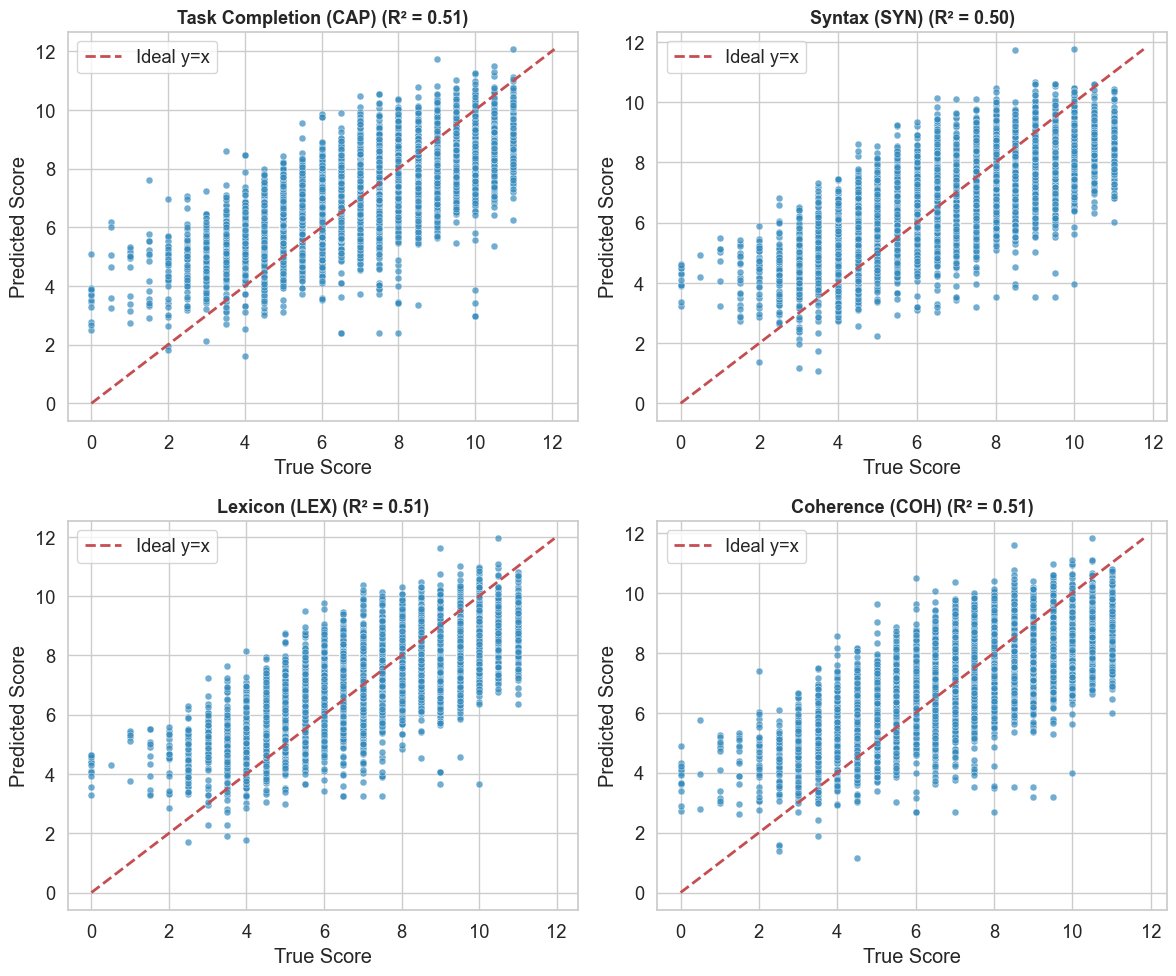

In [457]:
# ------------------------------------------------------------
# Étape 4 : Visualisation améliorée (True vs Predicted)
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

sns.set(style="whitegrid", font_scale=1.2)
subnotes = ["note_cap", "note_syn", "note_lex", "note_coh"]
titles = ["Task Completion (CAP)", "Syntax (SYN)", "Lexicon (LEX)", "Coherence (COH)"]

plt.figure(figsize=(12, 10))

for i, sub in enumerate(subnotes):
    y_true = y_test[sub]
    y_pred_sub = y_pred[:, i]
    r2 = r2_score(y_true, y_pred_sub)

    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=y_true, y=y_pred_sub, s=25, color="#348ABD", alpha=0.7, edgecolor="white")
    
    # Ligne y=x
    min_val = min(y_true.min(), y_pred_sub.min())
    max_val = max(y_true.max(), y_pred_sub.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Ideal y=x")
    
    # Titres et labels
    plt.title(f"{titles[i]} (R² = {r2:.2f})", fontsize=13, weight='bold')
    plt.xlabel("True Score")
    plt.ylabel("Predicted Score")
    plt.legend(loc="upper left")

plt.tight_layout()
plt.show()


In [459]:
# Sauvegarde du graphique dans un dossier 'figures'
plt.savefig("/Users/raymondmauricefaye/Desktop/baseline_tfidf_ridge_subscores.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

# PREPARATION DU DATASET POUR LE MODELE TRANSFORMER

## 4. Transformer Model Training

In this section, we fine-tune a CamemBERT model to predict the writing score based on the full textual input.

The process includes:

- Tokenization of the input text
- Preparation of training and validation datasets
- Model fine-tuning using the HuggingFace Trainer
- Monitoring evaluation metrics during training

In [ ]:
import pandas as pd

df_model3 = pd.read_csv("df_model_clean.csv")
df_model3.head()

In [ ]:
# Calcul des bornes min et max
min_score = df_model3["score_brut"].min()
max_score = df_model3["score_brut"].max()

# Création d'une nouvelle colonne normalisée
df_model3["score_normalisé"] = (df_model3["score_brut"] - min_score) / (max_score - min_score)

# Vérification
print(f"Min: {df_model3['score_normalisé'].min():.2f}, Max: {df_model3['score_normalisé'].max():.2f}")
df_model3[["score_brut", "score_normalisé"]].head()


In [233]:
# 🧠 Création d’un full_input bien structuré avec séparation nette
df_model3["full_input"] = (
    "[SUJET] : " + df_model3["Nom_Sujet"].fillna("") + "\n\n" +
    "[INTRODUCTION] : " + df_model3["Introduction"].fillna("") + "\n\n" +
    "[TEXTE_1] : " + df_model3["Texte1"].fillna("") + "\n\n" +
    "[TEXTE_2] : " + df_model3["Texte2"].fillna("") +
    " </s> " +  # séparation forte
    "[REPONSE] : " + df_model3["response"].fillna("")
)

# 🔍 Vérification rapide
print(df_model3["full_input"].sample(1).values[0][:500])
 # affiche les 500 premiers caractères d'un exemple


[SUJET] : Dans 20 ans

[INTRODUCTION] : Vous avez lu dans un journal l'affirmation suivante :

[TEXTE_1] : « Dans 20 ans, il ny aura plus de livres »

[TEXTE_2] : Écrivez une lettre au journal pour dire ce que vous en pensez (200 mots minimum). Développez au moins 3 arguments pour défendre votre point de vue. </s> [REPONSE] : 

Monsieur le redacteur en chef,

La raison pour laquelle je me permets de vous écrire cette lettre, ce par rapport à votre affirmation où vous affirme que les livres vont


In [235]:
from sklearn.model_selection import train_test_split

# On sélectionne les colonnes utiles
columns = ["full_input", "score_normalisé"]

# Séparation train / test
df_train3, df_test3 = train_test_split(df_model3[columns], test_size=0.3, random_state=42)

# Vérification
print(f"Train shape : {df_train3.shape}, Test shape : {df_test3.shape}")
print("Extrait exemple (train) :", df_train3.iloc[0]["full_input"][:300])


Train shape : (57614, 2), Test shape : (24692, 2)
Extrait exemple (train) : [SUJET] : Destination ailleurs

[INTRODUCTION] : Voici le début d'un article de presse ;

[TEXTE_1] : Terminez cet article : en ajoutant à la suite un texte de 80 mots minimum ; en faisant plusieurs paragraphes.

[TEXTE_2] : Destination ailleurs 30 minutes avant d'atterrir à laéroport de Bali (Indo


In [237]:
from transformers import AutoTokenizer
from datasets import Dataset

# Chargement du tokenizer CamemBERTv2
tokenizer3 = AutoTokenizer.from_pretrained("almanach/camembertv2-base")

# Définition de la fonction de tokenisation
def tokenize_function(example):
    return tokenizer(
        example["full_input"],
        truncation=True,
        padding="max_length",
        max_length=1024  # CamemBERTv2 accepte jusqu'à 1024 tokens
    )

# Conversion en Dataset HuggingFace
train_dataset3 = Dataset.from_pandas(df_train3)
test_dataset3 = Dataset.from_pandas(df_test3)

# Application du tokenizer
train_dataset3 = train_dataset3.map(tokenize_function, batched=True)
test_dataset3 = test_dataset3.map(tokenize_function, batched=True)

# Nettoyage des colonnes inutiles
train_dataset3 = train_dataset3.remove_columns(["full_input"])
test_dataset3 = test_dataset3.remove_columns(["full_input"])

# Renommer "score_normalisé" en "labels" pour que Trainer fonctionne
train_dataset3 = train_dataset3.rename_column("score_normalisé", "labels")
test_dataset3 = test_dataset3.rename_column("score_normalisé", "labels")


Map:   0%|          | 0/57614 [00:00<?, ? examples/s]

Map:   0%|          | 0/24692 [00:00<?, ? examples/s]

In [241]:
import torch
import torch.nn as nn
from transformers import AutoModel

class CamemBERTv2AttentionPooling(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = AutoModel.from_pretrained("almanach/camembertv2-base")

        hidden_size = self.model.config.hidden_size

        # Attention learnable sur les tokens
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.Tanh(),
            nn.Linear(512, 1)  # score scalaire pour chaque token
        )

        self.regressor = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state  # (batch_size, seq_len, hidden)

        # Masque attention : -inf pour les tokens padding
        attn_scores = self.attention(hidden_states).squeeze(-1)  # (batch_size, seq_len)
        attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1)  # (batch_size, seq_len)

        # Weighted sum : (batch_size, hidden)
        weighted_output = torch.sum(hidden_states * attn_weights.unsqueeze(-1), dim=1)

        logits = self.regressor(weighted_output).squeeze(-1)

        loss = None
        if labels is not None:
            loss_fn = nn.MSELoss()
            loss = loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}


In [245]:
model3 = CamemBERTv2AttentionPooling()


Some weights of RobertaModel were not initialized from the model checkpoint at almanach/camembertv2-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [247]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.squeeze(predictions)
    rmse = mean_squared_error(labels, predictions, squared=False)
    mae = mean_absolute_error(labels, predictions)
    r2 = r2_score(labels, predictions)
    return {"rmse": rmse, "mae": mae, "r2": r2}


In [249]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_attention",
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,  
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)


/opt/anaconda3/lib/python3.12/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [251]:
from transformers import Trainer, DataCollatorWithPadding

data_collator3 = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model3,
    args=training_args,
    train_dataset=train_dataset3,
    eval_dataset=test_dataset3,
    tokenizer=tokenizer3,
    data_collator=data_collator3,
    compute_metrics=compute_metrics
)

trainer.train()


/var/folders/s3/lpz20rx549gf1235nk0nrdww0000gn/T/ipykernel_6588/702373036.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Rmse,Mae,R2
1,0.017700,0.016289,0.127627,0.101702,0.509982
2,0.014500,0.018678,0.136666,0.108777,0.438112
3,0.012200,0.019925,0.141158,0.112006,0.400574


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


TrainOutput(global_step=43212, training_loss=0.014795717018506686, metrics={'train_runtime': 281568.4559, 'train_samples_per_second': 0.614, 'train_steps_per_second': 0.153, 'total_flos': 0.0, 'train_loss': 0.014795717018506686, 'epoch': 3.0})

In [253]:
# 📁 Sauvegarde du meilleur modèle
trainer.save_model("camembertv2_attention_best_model")
tokenizer.save_pretrained("camembertv2_attention_best_model")


('camembertv2_attention_best_model/tokenizer_config.json',
 'camembertv2_attention_best_model/special_tokens_map.json',
 'camembertv2_attention_best_model/vocab.txt',
 'camembertv2_attention_best_model/added_tokens.json',
 'camembertv2_attention_best_model/tokenizer.json')

In [255]:
# 🔮 Prédictions sur le jeu de test
predictions = trainer.predict(test_dataset)

# Récupération des prédictions
y_pred = predictions.predictions.squeeze()


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [390]:
# Remettre les index à plat si besoin
df_test = df_test.reset_index(drop=True)

# Ajout des prédictions dans une nouvelle colonne
df_test["pred_score_normalisé"] = y_pred

# Re-transformer les scores normalisés vers l’échelle d’origine (optionnel)
min_score = df_model["score_brut"].min()
max_score = df_model["score_brut"].max()

df_test["pred_score_brut"] = df_test["pred_score_normalisé"] * (max_score - min_score) + min_score


In [392]:
# Vérifie les colonnes de ton dataframe
print(df_test.columns)


Index(['full_input', 'score_normalisé', 'pred_score_normalisé',
       'pred_score_brut', 'Nom_Sujet', 'section'],
      dtype='object')


In [118]:
df_final_notes

,candidate,subject,title,response,Nom_Sujet,Introduction,Texte1,Texte2,section,session_id,fda_evaluator_id,note_cap,note_syn,note_lex,note_coh,score_brut,score_section_eval,score_evaluateur,score_epreuve
0,11303,EE20153B,TEF Canada - TEF_EE2,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,EE2,7004962,7083,9,8,9,9,110.5,271,521.0,542.0
1,11303,EE20153B,TEF Canada - TEF_EE2,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,EE2,7004962,7101,9,9,9,9,112.5,275,563.0,542.0
2,11303,EE20160A,TEF Canada - TEF_EE1,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",EE1,7004962,7083,8,8,8,8,100.0,250,521.0,542.0
3,11303,EE20160A,TEF Canada - TEF_EE1,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",EE1,7004962,7101,10,9,9,9,119.0,288,563.0,542.0
4,3644,EE20129A,TEF Canada - TEF_EE1,"une arme. \nEn effet, le jeune homme dépassant...",Un rendez-vous urgent,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar...",EE1,7001192,7085,11,9,11,11,133.5,333,667.0,592.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84435,19746,EE20141B,TEF Québec - TEF_EE2,06/08/2024\n \nSujet: Addict...,Addiction aux réseaux,Vous avez lu dans un journal l'affirmation sui...,« Addiction aux réseaux sociaux : les adultes ...,Écrivez une lettre au journal pour dire ce que...,EE2,7007858,7143,6,6,6,6,75.0,200,379.0,404.0
84436,16475,EE20170A,TEF Canada - TEF_EE1,Le canapé acheté à un prix très abordable pa...,Une très bonne affaire,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Une très bonne affaire Un retraité de Vesoul (...,EE1,7006943,7141,8,8,7,8,98.0,246,471.0,481.0
84437,16475,EE20170A,TEF Canada - TEF_EE1,Le canapé acheté à un prix très abordable pa...,Une très bonne affaire,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Une très bonne affaire Un retraité de Vesoul (...,EE1,7006943,7194,8,7,8,8,98.0,246,492.0,481.0
84438,16475,EE20147B,TEF Canada - TEF_EE2,"Bonjour Monsieur, j ai lu dans dans un journal...",Dans cette société des écrans,Vous avez lu dans un journal l'affirmation sui...,"« Dans cette société des écrans et de limage,...",Écrivez une lettre au journal pour dire ce que...,EE2,7006943,7141,7,7,7,7,87.5,225,471.0,481.0


In [120]:
cols_to_drop = [
   
   'title', 'score_section_eval', 'score_evaluateur', 'score_epreuve'
]

df_model = df_final_notes.drop(columns=cols_to_drop)

In [122]:
df_model

,candidate,subject,response,Nom_Sujet,Introduction,Texte1,Texte2,section,session_id,fda_evaluator_id,note_cap,note_syn,note_lex,note_coh,score_brut
0,11303,EE20153B,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,EE2,7004962,7083,9,8,9,9,110.5
1,11303,EE20153B,"A l'attention de la rédaction, je v...",Avoir du talent,Vous avez lu dans un journal l'affirmation sui...,"« De nos jours, il nest pas nécessaire davoi...",Écrivez une lettre au journal pour dire ce que...,EE2,7004962,7101,9,9,9,9,112.5
2,11303,EE20160A,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",EE1,7004962,7083,8,8,8,8,100.0
3,11303,EE20160A,En effet étant en route pour leur domicile ...,Passage secret,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Passage secret (Liverpool, Angleterre) Samedi ...",EE1,7004962,7101,10,9,9,9,119.0
4,3644,EE20129A,"une arme. \nEn effet, le jeune homme dépassant...",Un rendez-vous urgent,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar...",EE1,7001192,7085,11,9,11,11,133.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84435,19746,EE20141B,06/08/2024\n \nSujet: Addict...,Addiction aux réseaux,Vous avez lu dans un journal l'affirmation sui...,« Addiction aux réseaux sociaux : les adultes ...,Écrivez une lettre au journal pour dire ce que...,EE2,7007858,7143,6,6,6,6,75.0
84436,16475,EE20170A,Le canapé acheté à un prix très abordable pa...,Une très bonne affaire,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Une très bonne affaire Un retraité de Vesoul (...,EE1,7006943,7141,8,8,7,8,98.0
84437,16475,EE20170A,Le canapé acheté à un prix très abordable pa...,Une très bonne affaire,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,Une très bonne affaire Un retraité de Vesoul (...,EE1,7006943,7194,8,7,8,8,98.0
84438,16475,EE20147B,"Bonjour Monsieur, j ai lu dans dans un journal...",Dans cette société des écrans,Vous avez lu dans un journal l'affirmation sui...,"« Dans cette société des écrans et de limage,...",Écrivez une lettre au journal pour dire ce que...,EE2,7006943,7141,7,7,7,7,87.5


In [124]:
# Colonnes à moyenner
note_cols = ["note_cap", "note_syn", "note_lex", "note_coh", "score_brut"]

# Clés d'identification d'une même copie
group_keys = ["candidate", "Nom_Sujet", "response"]

# Calcul de la moyenne par copie
df_avg = df_model.groupby(group_keys, as_index=False)[note_cols].mean()


In [126]:
df_avg

,candidate,Nom_Sujet,response,note_cap,note_syn,note_lex,note_coh,score_brut
0,1,Le travail à distance,"A Paris, le 10 novembre 2023,\nA l'attention d...",10.5,9.5,10.5,10.0,128.25
1,1,Un rendez-vous urgent,"En effet, ce motard avait sur sa main gauche u...",11.0,11.0,11.0,10.5,136.50
2,2,Pour prévenir les crimes,"C'est un fait, les crimes sont de plus en plus...",10.5,9.5,10.0,9.5,126.25
3,2,Un trésor original,Alors même que leurs recherches etaient vaines...,10.5,10.0,10.5,10.0,129.25
4,3,Chaque citoyen,"Monsieur le rédacteur en chef,\nJe vous écris ...",9.0,8.5,9.0,9.0,111.50
...,...,...,...,...,...,...,...,...
42215,21415,Mauvaises perdantes,"Samedi dernier,vers 10 heures du matin, dans u...",8.0,7.5,7.5,8.0,98.00
42216,21416,L'apprentissage d'un instrument de musique,"Bonjour Monsieur le rédacteur en chef, \n\nJe ...",6.5,6.0,6.5,6.5,80.25
42217,21416,Une très bonne affaire,"La semaine dernière, Alfred, un retraité a vou...",6.0,5.0,6.0,5.5,72.00
42218,21418,Déjà prisonnier !,"Mardi dernier, dans un petite ville près de la...",6.5,5.0,6.0,5.5,75.25


In [128]:
text_cols = ["subject", "Introduction", "Texte1", "Texte2", "section"]

df_text = df_model.groupby(group_keys, as_index=False)[text_cols].first()

# Puis fusionner avec les moyennes
df_final = df_avg.merge(df_text, on=group_keys)


# SUBNOTE PREDICTOR : entraînement du modèle de prédiction des 4 sous-notes

## 5. Subscore Prediction Model

To better capture the evaluation criteria used in TEF assessments, we train a dedicated model to predict the four subscores associated with the writing task.

These subscores correspond to different evaluation dimensions such as:

- Task achievement
- Coherence and organization
- Lexical richness
- Grammatical accuracy

The model architecture incorporates attention pooling and a regression head to estimate the four subscores simultaneously.

In [174]:
df_final.head()

,candidate,Nom_Sujet,response,note_cap,note_syn,note_lex,note_coh,score_brut,subject,Introduction,Texte1,Texte2,section
0,1,Le travail à distance,"A Paris, le 10 novembre 2023,\nA l'attention d...",10.5,9.5,10.5,10.0,128.25,EE20129B,Vous avez lu dans un journal l'affirmation sui...,« Le travail à distance devrait être la règle ...,Écrivez une lettre au journal pour dire ce que...,EE2
1,1,Un rendez-vous urgent,"En effet, ce motard avait sur sa main gauche u...",11.0,11.0,11.0,10.5,136.50,EE20129A,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un rendez-vous urgent (Milan, Italie) Un motar...",EE1
2,2,Pour prévenir les crimes,"C'est un fait, les crimes sont de plus en plus...",10.5,9.5,10.0,9.5,126.25,EE20130B,Vous avez lu dans un journal l'affirmation sui...,"« Pour prévenir les crimes, il faudrait généra...",Écrivez une lettre au journal pour dire ce que...,EE2
3,2,Un trésor original,Alors même que leurs recherches etaient vaines...,10.5,10.0,10.5,10.0,129.25,EE20127A,Voici le début d'un article de presse ;,Terminez cet article : en ajoutant à la suite ...,"Un trésor original (La Havane, Cuba) Deux écol...",EE1
4,3,Chaque citoyen,"Monsieur le rédacteur en chef,\nJe vous écris ...",9.0,8.5,9.0,9.0,111.50,EE20128B,Vous avez lu dans un journal l'affirmation sui...,« Chaque citoyen devrait sengager dans une as...,Écrivez une lettre au journal pour dire ce que...,EE2


In [176]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

unique_candidats = df_final['candidate'].unique()
np.random.seed(42)
np.random.shuffle(unique_candidats)

n_total = len(unique_candidats)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_ids = unique_candidats[:n_train]
val_ids = unique_candidats[n_train:n_train + n_val]
test_ids = unique_candidats[n_train + n_val:]

df_train = df_final[df_final['candidate'].isin(train_ids)].reset_index(drop=True)
df_val   = df_final[df_final['candidate'].isin(val_ids)].reset_index(drop=True)
df_test  = df_final[df_final['candidate'].isin(test_ids)].reset_index(drop=True)

# Vérification chevauchements
assert not set(train_ids).intersection(val_ids)
assert not set(train_ids).intersection(test_ids)
assert not set(val_ids).intersection(test_ids)

print("✅ Découpage par candidat réussi sans chevauchement.")


✅ Découpage par candidat réussi sans chevauchement.


In [178]:
min_score = df_train["score_brut"].min()
max_score = df_train["score_brut"].max()

df_train["score_brut_norm"] = (df_train["score_brut"] - min_score) / (max_score - min_score)
df_val["score_brut_norm"]   = (df_val["score_brut"]   - min_score) / (max_score - min_score)
df_test["score_brut_norm"]  = (df_test["score_brut"]  - min_score) / (max_score - min_score)


In [180]:
def build_full_input(row):
    return (
        "Sujet : "        + str(row["Nom_Sujet"] or "")      + "\n\n"
        "Introduction : " + str(row["Introduction"] or "")   + "\n\n"
        "Texte 1 : "      + str(row["Texte1"] or "")         + "\n\n"
        "Texte 2 : "      + str(row["Texte2"] or "")         + "\n\n"
        " </s> " +
        "Réponse : "      + str(row["response"] or "")
    )

for df in [df_train, df_val, df_test]:
    if 'full_input' not in df.columns:
        df["full_input"] = df.apply(build_full_input, axis=1)


# Entraîner SubnotePredictor


## Étape 1 : Créer le modèle SubnotePredictor
Ce modèle prendra uniquement le texte (full_input) en entrée, et prédira les 4 sous-notes normalisées : note_cap, note_syn, note_lex, note_coh.

In [338]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig, PreTrainedModel

class SubnotePredictor(PreTrainedModel):
    config_class = AutoConfig  # nécessaire pour .from_pretrained()

    def __init__(self, config=None):
        if config is None:
            config = AutoConfig.from_pretrained("almanach/camembertv2-base")

        super().__init__(config)
        self.model = AutoModel.from_pretrained("almanach/camembertv2-base", config=config)
        self.hidden_size = self.model.config.hidden_size

        # Pooling attention (inchangé)
        self.attn = nn.Sequential(
            nn.Linear(self.hidden_size, 512),
            nn.Tanh(),
            nn.Linear(512, 1)
        )

        # ✅ Tête de régression robuste
        self.regressor = nn.Sequential(
            nn.Linear(self.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 4),
            nn.Sigmoid()  # car les sous-notes sont entre 0 et 1
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state  # (B, L, H)

        # Attention pooling
        attn_scores = self.attn(hidden_states).squeeze(-1)  # (B, L)
        attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1)
        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)

        pooled = torch.bmm(attn_weights.unsqueeze(1), hidden_states).squeeze(1)  # (B, H)

        # 🔁 Passage dans la tête de régression
        preds = self.regressor(pooled)

        # Calcul de la perte
        loss = None
        if labels is not None:
            loss = nn.functional.mse_loss(preds, labels)

        return {"loss": loss, "logits": preds} if loss is not None else {"logits": preds}


## Étape 2 : Dataset PyTorch pour les sous-notes (SubnoteDataset)
Ce dataset prendra comme entrée uniquement le full_input (texte), et comme cible un vecteur de 4 sous-notes normalisées.

In [341]:
from torch.utils.data import Dataset
import torch

class SubnoteDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=1024):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        encoded = self.tokenizer(
            row["full_input"],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        target = torch.tensor([
            row["note_cap"] / 11.0,
            row["note_syn"] / 11.0,
            row["note_lex"] / 11.0,
            row["note_coh"] / 11.0
        ], dtype=torch.float32)

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": target
        }


## Étape 3.1 : DataCollator pour les sous-notes

In [344]:
from transformers import default_data_collator
data_collator_subnotes = default_data_collator


## Étape 3.2 : Création des datasets pour l’entraînement

In [347]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("almanach/camembertv2-base")

train_dataset_sub = SubnoteDataset(df_train, tokenizer, max_length=1024)
val_dataset_sub   = SubnoteDataset(df_val, tokenizer, max_length=1024)


## Étape 4.1 : Arguments d’entraînement pour SubnotePredictor

In [382]:
from transformers import TrainingArguments, EarlyStoppingCallback

from transformers import TrainingArguments


training_args_sub = TrainingArguments(
    output_dir              = "./results_subnotes_final",  # 📁 Chemin de sauvegarde
    per_device_train_batch_size = 1,
    per_device_eval_batch_size  = 1,
    num_train_epochs        = 3,              # ⏱ Max epochs (early stopping arrêtera avant)
    learning_rate           = 1e-5,            # 🔧 LR stable pour fine-tuning Transformer
    weight_decay            = 0.01,            # 🔒 L2 régularisation

    warmup_ratio            = 0.1,             # 🔥 Warmup 10%
    lr_scheduler_type       = "cosine",        # 🔄 Scheduler stable pour ne pas chuter brutalement

    evaluation_strategy     = "epoch",
    save_strategy           = "epoch",
    load_best_model_at_end  = True,
    metric_for_best_model   = "r2",
    greater_is_better       = True,
    save_total_limit        = 2,

    logging_dir             = "./logs_subnotes_final",
    logging_strategy        = "steps",
    logging_steps           = 20,              # 📊 Logs fréquents
    report_to               = "none",

    fp16                    = False,           # 🔒 plus stable sans fp16 sur Mac MPS
    remove_unused_columns   = False,           # ⚠️ important pour Trainer + custom Dataset
)



from transformers import EarlyStoppingCallback
callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]


/opt/anaconda3/lib/python3.12/site-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


## Étape 4.2 : Fonction de métriques pour les sous-notes

In [384]:
from transformers import TrainingArguments
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def compute_metrics_sub(eval_pred):
    preds, labels = eval_pred
    preds = np.asarray(preds).reshape(-1, 4)
    labels = np.asarray(labels).reshape(-1, 4)

    print("🔍 Exemple de prédictions :", preds[:5])
    print("🔍 Exemple de labels :", labels[:5])

    mask = (
        ~np.isnan(preds).any(axis=1) &
        ~np.isinf(preds).any(axis=1) &
        ~np.isnan(labels).any(axis=1) &
        ~np.isinf(labels).any(axis=1)
    )
    preds  = preds[mask]
    labels = labels[mask]

    if len(labels) == 0:
        print("⚠️ Tous les labels ou prédictions sont NaN/Inf après filtrage.")
        return {"rmse": np.nan, "mae": np.nan, "r2": np.nan}

    return {
        "rmse": mean_squared_error(labels, preds, squared=False),
        "mae": mean_absolute_error(labels, preds),
        "r2": r2_score(labels, preds),
    }


## Étape 4.3 : Instanciation et entraînement

In [357]:
del model_sub
torch.cuda.empty_cache()  # ou torch.mps.empty_cache() selon ton device

# Réinstanciation propre
model_sub = SubnotePredictor().to(device)


Some weights of RobertaModel were not initialized from the model checkpoint at almanach/camembertv2-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [387]:
# Recrée le trainer avec le modèle neuf
trainer_sub = Trainer(
    model           = model_sub,
    args            = training_args_sub,
    train_dataset   = train_dataset_sub,
    eval_dataset    = val_dataset_sub,
    tokenizer       = tokenizer,
    data_collator   = data_collator_subnotes,
    compute_metrics = compute_metrics_sub,
    callbacks       = callbacks
)



/var/folders/s3/lpz20rx549gf1235nk0nrdww0000gn/T/ipykernel_84267/1283966116.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_sub = Trainer(


In [389]:

# ⏱️ Lancer l'entraînement
trainer_sub.train()

# 📊 Évaluation finale
eval_results = trainer_sub.evaluate()
print("📈 Résultats finaux SubnotePredictor :")
print(eval_results)

Epoch,Training Loss,Validation Loss,Rmse,Mae,R2
1,0.005200,0.009982,0.099873,0.078521,0.633312
2,0.011100,0.009696,0.098429,0.077881,0.643834
3,0.005300,0.010991,0.104808,0.082983,0.596223


🔍 Exemple de prédictions : [[0.8554137  0.83364296 0.850518   0.85354555]
 [0.8670014  0.8470451  0.8632482  0.8663741 ]
 [0.87382555 0.85687506 0.8728963  0.87385684]
 [0.81574947 0.7999786  0.81753397 0.81631064]
 [0.7417962  0.71544605 0.73895705 0.7386434 ]]
🔍 Exemple de labels : [[0.95454544 0.8636364  0.90909094 0.8636364 ]
 [0.95454544 0.90909094 0.95454544 0.90909094]
 [0.90909094 0.90909094 0.90909094 0.90909094]
 [0.8636364  0.90909094 0.90909094 0.90909094]
 [1.         0.90909094 0.95454544 0.90909094]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


🔍 Exemple de prédictions : [[0.86305195 0.83963567 0.85914093 0.85187435]
 [0.904223   0.883991   0.89876115 0.89367   ]
 [0.9025102  0.88529944 0.8998921  0.89302045]
 [0.8716568  0.8532796  0.8687274  0.86311024]
 [0.7686413  0.7385603  0.7644224  0.75535315]]
🔍 Exemple de labels : [[0.95454544 0.8636364  0.90909094 0.8636364 ]
 [0.95454544 0.90909094 0.95454544 0.90909094]
 [0.90909094 0.90909094 0.90909094 0.90909094]
 [0.8636364  0.90909094 0.90909094 0.90909094]
 [1.         0.90909094 0.95454544 0.90909094]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


🔍 Exemple de prédictions : [[0.8997518  0.8774078  0.89563787 0.8923439 ]
 [0.91561484 0.89570093 0.9115308  0.9086529 ]
 [0.91464937 0.8968455  0.91244066 0.9083154 ]
 [0.90252537 0.8876294  0.90283465 0.8986536 ]
 [0.79598814 0.75876045 0.7868656  0.7830703 ]]
🔍 Exemple de labels : [[0.95454544 0.8636364  0.90909094 0.8636364 ]
 [0.95454544 0.90909094 0.95454544 0.90909094]
 [0.90909094 0.90909094 0.90909094 0.90909094]
 [0.8636364  0.90909094 0.90909094 0.90909094]
 [1.         0.90909094 0.95454544 0.90909094]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


🔍 Exemple de prédictions : [[0.86305195 0.83963567 0.85914093 0.85187435]
 [0.904223   0.883991   0.89876115 0.89367   ]
 [0.9025102  0.88529944 0.8998921  0.89302045]
 [0.8716568  0.8532796  0.8687274  0.86311024]
 [0.7686413  0.7385603  0.7644224  0.75535315]]
🔍 Exemple de labels : [[0.95454544 0.8636364  0.90909094 0.8636364 ]
 [0.95454544 0.90909094 0.95454544 0.90909094]
 [0.90909094 0.90909094 0.90909094 0.90909094]
 [0.8636364  0.90909094 0.90909094 0.90909094]
 [1.         0.90909094 0.95454544 0.90909094]]
📈 Résultats finaux SubnotePredictor :
{'eval_loss': 0.009695513173937798, 'eval_rmse': 0.09842945635318756, 'eval_mae': 0.07788057625293732, 'eval_r2': 0.6438343773348025, 'eval_runtime': 564.4162, 'eval_samples_per_second': 11.219, 'eval_steps_per_second': 11.219, 'epoch': 3.0}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [391]:
import torch

# 📁 Crée un dossier de sauvegarde si besoin
save_dir = "./model_subnote_final"
os.makedirs(save_dir, exist_ok=True)

# 💾 Sauvegarde des poids (état du modèle uniquement)
torch.save(model_sub.state_dict(), os.path.join(save_dir, "subnote_weights.pth"))

print("✅ Modèle SubnotePredictor sauvegardé avec succès dans :", save_dir)


✅ Modèle SubnotePredictor sauvegardé avec succès dans : ./model_subnote_final


In [395]:
tokenizer.save_pretrained("./model_subnote_final")


('./model_subnote_final/tokenizer_config.json',
 './model_subnote_final/special_tokens_map.json',
 './model_subnote_final/vocab.txt',
 './model_subnote_final/added_tokens.json',
 './model_subnote_final/tokenizer.json')

In [399]:
# Charger le tokenizer et le modèle depuis le dossier final
tokenizer = AutoTokenizer.from_pretrained("./model_subnote_final")

model_sub = SubnotePredictor()
model_sub.load_state_dict(torch.load("./model_subnote_final/subnote_weights.pth", map_location="mps"))
model_sub.eval()
model_sub = model_sub.to("mps")


Some weights of RobertaModel were not initialized from the model checkpoint at almanach/camembertv2-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/s3/lpz20rx549gf1235nk0nrdww0000gn/T/ipykernel_84267/3881321853.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by th

# Évaluer le modèle sur le test set (df_test)

In [464]:
test_dataset_sub = SubnoteDataset(df_test, tokenizer, max_length=1024)

from torch.utils.data import DataLoader

test_loader_sub = DataLoader(
    test_dataset_sub,
    batch_size=1,
    shuffle=False,
    collate_fn=data_collator_subnotes
)


In [478]:
model_sub.eval()
cap_preds, syn_preds, lex_preds, coh_preds = [], [], [], []

with torch.no_grad():
    for batch in test_loader_sub:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        output = model_sub(input_ids=input_ids, attention_mask=attention_mask)
        preds = output["logits"].squeeze(0).cpu().numpy()  # shape: (4,)

        # ✅ Cast explicite pour garantir un float, pas de Series parasites
        cap_preds.append(float(preds[0] * 11))
        syn_preds.append(float(preds[1] * 11))
        lex_preds.append(float(preds[2] * 11))
        coh_preds.append(float(preds[3] * 11))


In [490]:
df_test["note_cap_pred"] = cap_preds
df_test["note_syn_pred"] = syn_preds
df_test["note_lex_pred"] = lex_preds
df_test["note_coh_pred"] = coh_preds


In [492]:
print(df_test[["note_cap_pred", "note_syn_pred", "note_lex_pred", "note_coh_pred"]].dtypes)


note_cap_pred    float64
note_syn_pred    float64
note_lex_pred    float64
note_coh_pred    float64
dtype: object


In [494]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n📊 📈 Évaluation des sous-notes sur le TEST SET :")
for subnote in ["cap", "syn", "lex", "coh"]:
    y_true = df_test[f"note_{subnote}"]
    y_pred = df_test[f"note_{subnote}_pred"]

    print(f"\n▶️ {subnote.upper()} :")
    print(f"  RMSE : {mean_squared_error(y_true, y_pred, squared=False):.4f}")
    print(f"  MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"  R²   : {r2_score(y_true, y_pred):.4f}")



📊 📈 Évaluation des sous-notes sur le TEST SET :

▶️ CAP :
  RMSE : 1.1477
  MAE  : 0.8886
  R²   : 0.6276

▶️ SYN :
  RMSE : 1.1101
  MAE  : 0.8769
  R²   : 0.6520

▶️ LEX :
  RMSE : 1.0680
  MAE  : 0.8388
  R²   : 0.6568

▶️ COH :
  RMSE : 1.1342
  MAE  : 0.8922
  R²   : 0.6382


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 